In [1]:
import sys
import os
sys.path.append(os.pardir)

In [2]:
import numpy as np
import pandas as pd

In [3]:
from datetime import datetime, timedelta

In [4]:
import matplotlib.pyplot as plt

In [28]:
from skforecast.plot import calculate_lag_autocorrelation

In [29]:
"""
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from skforecast.plot import plot_residuals
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'font.size': 8})
"""

'\nimport matplotlib.pyplot as plt\nfrom statsmodels.graphics.tsaplots import plot_acf, plot_pacf\nfrom skforecast.plot import plot_residuals\nimport plotly.graph_objects as go\nimport plotly.io as pio\nimport plotly.offline as poff\npio.templates.default = "seaborn"\npoff.init_notebook_mode(connected=True)\nplt.style.use(\'seaborn-v0_8-darkgrid\')\nplt.rcParams.update({\'font.size\': 8})\n'

In [24]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [5]:
#df = pd.read_csv("../data/raw/tempload.csv", index_col = "date", parse_dates = True)
#need to drop duplicates
#idk why the extract script is buggy
#chain it all togther
# df isn't defined yet in the df["date"] call so we need to use pipe
df = (pd.read_csv("../data/raw/tempload.csv")
        .drop_duplicates()
        .pipe(lambda df: df.set_index(pd.to_datetime(df["date"])))
        .drop(columns = ["date"])
     )
#this will throw an error if there are duplicates
df.index = df.index.tz_localize(None)
df.index.freq = 'h'

In [6]:
# check that the index is complete
start_date = df.index.min()
end_date = df.index.max()
complete_date_range = pd.date_range(start=start_date, end=end_date, freq=df.index.freq)
is_index_complete = (df.index == complete_date_range).all()
print(f"Index complete: {is_index_complete}")
print(f"Number of rows with missing values: {df.isnull().any(axis=1).mean()}")

Index complete: True
Number of rows with missing values: 0.0009504257907542579


In [7]:
#check for rows with missing values
df[df.isnull().any(axis = 1)]

,Demand,Temperature,is_day
date,,,
2024-02-20 07:00:00,NaN,3.061500,0
2024-02-20 08:00:00,NaN,2.061500,0
2024-02-20 09:00:00,NaN,1.811500,0
2024-02-20 10:00:00,NaN,1.161500,0
2024-02-20 11:00:00,NaN,1.061500,0
2024-02-20 12:00:00,NaN,0.611500,0
2024-02-20 13:00:00,NaN,-0.288500,0
2024-02-20 14:00:00,NaN,1.011500,1
2024-02-20 15:00:00,NaN,5.011500,1


In [8]:
#handle the NA values in the demand column fill forward
df.sort_index()
df_clean = df.interpolate(method="linear", limit_direction="forward", axis=0)
df_clean[df_clean.isnull().any(axis = 1)]

,Demand,Temperature,is_day
date,,,


<Axes: xlabel='date'>

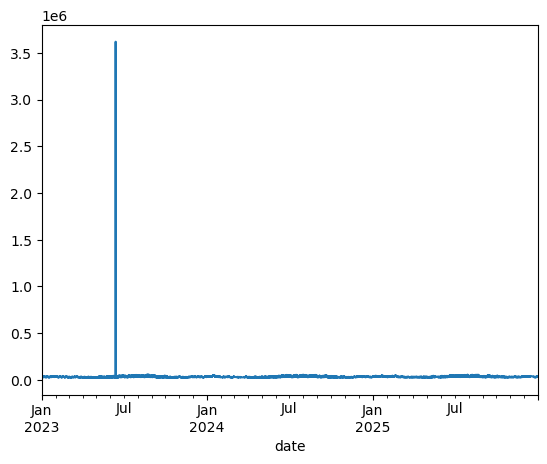

In [11]:
#check for outliers that could skew the data
df_clean.Demand.plot()

In [13]:
df_clean.Demand.describe()

count    2.630400e+04
mean     3.322343e+04
std      2.286381e+04
min      2.245600e+04
25%      2.916300e+04
50%      3.171800e+04
75%      3.579800e+04
max      3.621097e+06
Name: Demand, dtype: float64

In [14]:
df[df["Demand"] == df["Demand"].max()]

,Demand,Temperature,is_day
date,,,
2023-06-13 02:00:00,3621097.0,18.511501,0


In [15]:
#clearly there is an error the the data collection that we need to replace
df_clean["Demand"] = (df_clean["Demand"]
    .mask(df_clean["Demand"] == df_clean["Demand"].max())
    .interpolate(method="time")
)

<Axes: xlabel='date'>

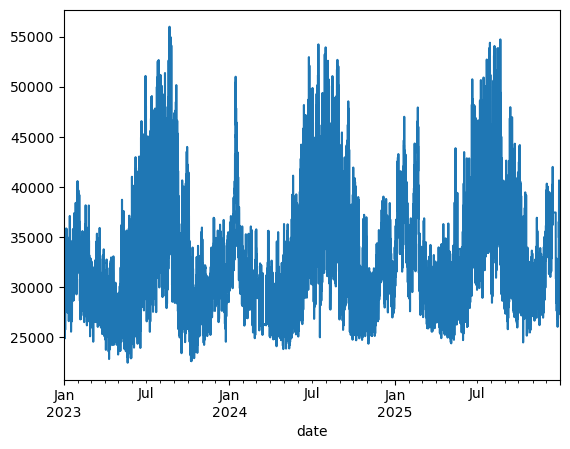

In [16]:
df_clean.Demand.plot()

In [17]:
#let's write the clean df to csv
df_clean.to_csv("../data/raw/loadtempday_clean.csv", index=True)

In [31]:
print(f"start of data: {df.index.min()}")
print(f"end of data: {df.index.max()}")

start of data: 2023-01-01 00:00:00
end of data: 2025-12-31 23:00:00


### Train Val Test Split
- Train: 2023-01-01 to 2024-06-30 (18 months)
- Validation: 2024-07-01 to 2024-12-31 (6 months)
- Test: 2025-01-01 to 2025-12-31 (12 months)

In [18]:
TRAIN_START = "2023-01-01 00:00:00"
#datetime(2023, 1, 1, 0, 0, 0)
TRAIN_END   = "2024-06-30 23:00:00"
#datetime(2024, 6, 30, 23, 0, 0)

VAL_START   = "2024-07-01 00:00:00"
#datetime(2024, 7, 1, 0, 0, 0)
VAL_END     = "2024-12-31 23:00:00"
#datetime(2024, 12, 31, 23, 0, 0)

TEST_START  = "2025-01-01 00:00:00"
#datetime(2025, 1, 1, 0, 0, 0)
TEST_END    = "2025-12-31 23:00:00"
#datetime(2025, 12, 31, 23, 0, 0)

In [19]:
data = df_clean.copy()
data_train = data.loc[: TRAIN_END, :].copy()
data_val   = data.loc[VAL_START:VAL_END, :].copy()
data_test  = data.loc[TEST_START:, :].copy()

print(f"Train dates      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Validation dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates      : 2023-01-01 00:00:00 --- 2024-06-30 23:00:00  (n=13128)
Validation dates : 2024-07-01 00:00:00 --- 2024-12-31 23:00:00  (n=4416)
Test dates       : 2025-01-01 00:00:00 --- 2025-12-31 23:00:00  (n=8760)


### Graphs

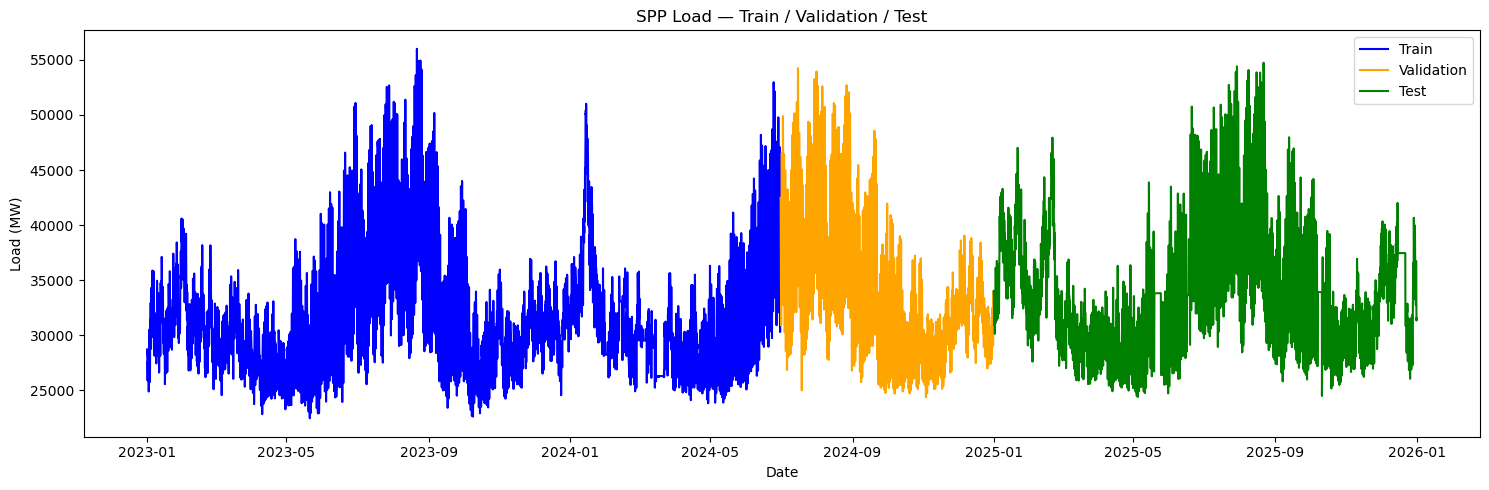

In [20]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_train.index, data_train["Demand"], label="Train", color="blue")
ax.plot(data_val.index, data_val["Demand"], label="Validation", color="orange")
ax.plot(data_test.index, data_test["Demand"], label="Test", color="green")

ax.set_title("SPP Load — Train / Validation / Test")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

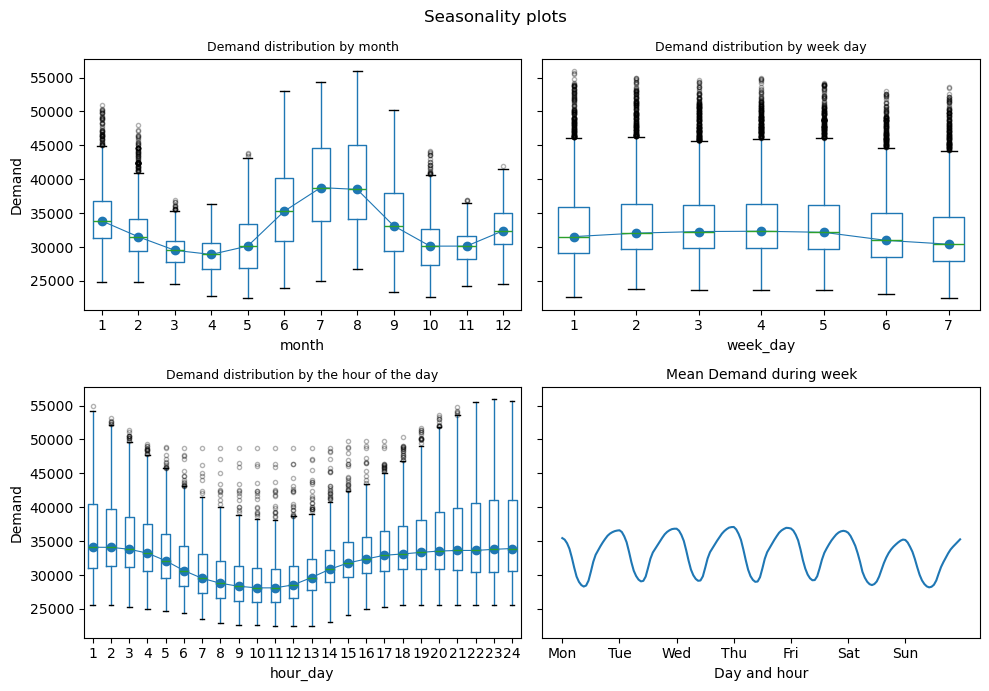

In [22]:
# Annual, weekly and daily seasonality
# ==============================================================================
fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=True)
axs = axs.ravel()

# Demand distribution by month
data['month'] = data.index.month
data.boxplot(column='Demand', by='month', ax=axs[0], flierprops={'markersize': 3, 'alpha': 0.3})
data.groupby('month')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[0])
axs[0].set_ylabel('Demand')
axs[0].set_title('Demand distribution by month', fontsize=9)

# Demand distribution by week day
data['week_day'] = data.index.day_of_week + 1
data.boxplot(column='Demand', by='week_day', ax=axs[1], flierprops={'markersize': 3, 'alpha': 0.3})
data.groupby('week_day')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[1])
axs[1].set_ylabel('Demand')
axs[1].set_title('Demand distribution by week day', fontsize=9)

# Demand distribution by the hour of the day
data['hour_day'] = data.index.hour + 1
data.boxplot(column='Demand', by='hour_day', ax=axs[2], flierprops={'markersize': 3, 'alpha': 0.3})
data.groupby('hour_day')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[2])
axs[2].set_ylabel('Demand')
axs[2].set_title('Demand distribution by the hour of the day', fontsize=9)

# Demand distribution by week day and hour of the day
mean_day_hour = data.groupby(["week_day", "hour_day"])["Demand"].mean()
mean_day_hour.plot(ax=axs[3])
axs[3].set(
    title       = "Mean Demand during week",
    xticks      = [i * 24 for i in range(7)],
    xticklabels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    xlabel      = "Day and hour",
    ylabel      = "Number of Demand"
)
axs[3].title.set_size(10)

fig.suptitle("Seasonality plots", fontsize=12)
fig.tight_layout()

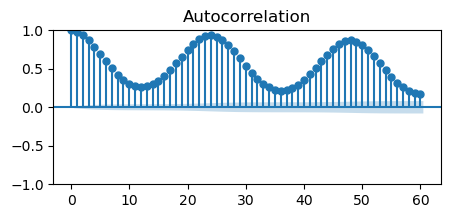

In [25]:
# Autocorrelation plot
fig, ax = plt.subplots(figsize=(5, 2))
plot_acf(data['Demand'], ax=ax, lags=60, fft=True)
plt.show()

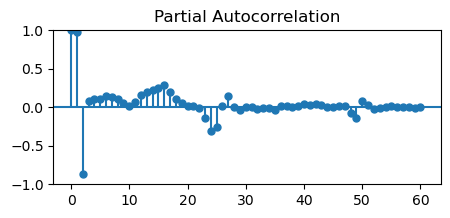

In [26]:
# Partial autocorrelation plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(5, 2))
plot_pacf(data['Demand'], ax=ax, lags=60, method='burg')
plt.show()

In [30]:
# Top 10 lags with the highest absolute partial autocorrelation
# ==============================================================================
calculate_lag_autocorrelation(
    data        = data['Demand'],
    n_lags      = 60,
    sort_by     = "partial_autocorrelation_abs",
    acf_kwargs  = {'fft': True},
    pacf_kwargs = {'method': 'burg'}
).head(10)

,lag,partial_autocorrelation_abs,partial_autocorrelation,autocorrelation_abs,autocorrelation
0,1,0.983448,0.983448,0.983433,0.983433
1,2,0.872132,-0.872132,0.938511,0.938511
2,24,0.313445,-0.313445,0.935476,0.935476
3,16,0.285086,0.285086,0.407027,0.407027
4,15,0.254537,0.254537,0.344922,0.344922
5,25,0.253179,-0.253179,0.918148,0.918148
6,14,0.220455,0.220455,0.299811,0.299811
7,17,0.197577,0.197577,0.483329,0.483329
8,13,0.197410,0.197410,0.273051,0.273051
9,12,0.155309,0.155309,0.265431,0.265431
